Taken from https://github.com/PacktPublishing/Deep-Learning-with-TensorFlow-2-and-Keras/blob/master/Chapter%209/VanillaAutoEncoder.ipynb
and details on usage by Gulli et al. (2019, Chapter 9)

References 

Gulli, A., Kapoor, A., & Pal, S. (2019). Deep Learning with TensorFlow 2 and Keras (2nd ed.). 	Packt Publishing. https://reader2.yuzu.com/books/9781838827724 

PacktPublishing. (2024). Deep-Learning-with-TensorFlow-2-and-Keras/Chapter 6/VanillaGAN.ipynb at master · PacktPublishing/Deep-Learning-with-TensorFlow-2-and-Keras. GitHub. https://github.com/PacktPublishing/Deep-Learning-with-TensorFlow-2-and-Keras/blob/master/Chapter%206/VanillaGAN.ipynb 

In [15]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as K
import matplotlib.pyplot as plt

In [16]:
np.random.seed(11)
tf.random.set_seed(11)
batch_size = 256
# max_epochs = 50
max_epochs = 10
learning_rate = 1e-3
momentum = 8e-1
hidden_dim = 128
original_dim = 784

In [17]:
(x_train, _), (x_test, _) = K.datasets.mnist.load_data()

x_train = x_train / 255.
x_test = x_test / 255.

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

x_train = np.reshape(x_train, (x_train.shape[0], 784))
x_test = np.reshape(x_test, (x_test.shape[0], 784))

training_dataset = tf.data.Dataset.from_tensor_slices(x_train).batch(batch_size)

In [18]:

class Encoder(K.layers.Layer):
    def __init__(self, hidden_dim):
        super(Encoder, self).__init__()
        self.hidden_layer = K.layers.Dense(units=hidden_dim, activation=tf.nn.relu)
        
    
    def call(self, input_features):
        activation = self.hidden_layer(input_features)
        return activation

In [19]:

class Decoder(K.layers.Layer):
    def __init__(self, hidden_dim, original_dim):
        super(Decoder, self).__init__()
        self.output_layer = K.layers.Dense(units=original_dim, activation=tf.nn.relu)
  
    def call(self, encoded):
        activation = self.output_layer(encoded)
        return activation 

In [20]:
class Autoencoder(K.Model):
    def __init__(self, hidden_dim, original_dim):
        super(Autoencoder, self).__init__()
        self.loss = []
        self.encoder = Encoder(hidden_dim=hidden_dim)
        self.decoder = Decoder(hidden_dim=hidden_dim, original_dim=original_dim)

    def call(self, input_features):
        encoded = self.encoder(input_features)
        reconstructed = self.decoder(encoded)
        return reconstructed

In [21]:
autoencoder = Autoencoder(hidden_dim=hidden_dim, original_dim=original_dim)
opt = tf.optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
def loss(preds, real):
    return tf.reduce_mean(tf.square(tf.subtract(preds, real)))

def train(loss, model, opt, original):
    with tf.GradientTape() as tape:
        preds = model(original)
        reconstruction_error = loss(preds, original)
    gradients = tape.gradient(reconstruction_error, model.trainable_variables)
    gradient_variables = zip(gradients, model.trainable_variables)
    opt.apply_gradients(gradient_variables)
  
    return reconstruction_error

In [22]:
def train_loop(model, opt, loss, dataset, epochs=20):
    for epoch in range(epochs):
        epoch_loss = 0
        for step, batch_features in enumerate(dataset):
            loss_values = train(loss, model, opt, batch_features)
            epoch_loss += loss_values
        model.loss.append(epoch_loss)
        print('Epoch {}/{}. Loss: {}'.format(epoch + 1, epochs, epoch_loss.numpy()))

In [23]:
autoencoder = Autoencoder(hidden_dim=hidden_dim, original_dim=original_dim)
opt = tf.keras.optimizers.Adam(learning_rate=1e-2)

train_loop(autoencoder, opt, loss, training_dataset, epochs=max_epochs)

Epoch 1/10. Loss: 4.997884273529053
Epoch 2/10. Loss: 3.205338478088379
Epoch 3/10. Loss: 3.0958621501922607
Epoch 4/10. Loss: 3.0786569118499756
Epoch 5/10. Loss: 3.0702672004699707
Epoch 6/10. Loss: 3.045905351638794
Epoch 7/10. Loss: 3.0187244415283203
Epoch 8/10. Loss: 3.032543897628784
Epoch 9/10. Loss: 3.057771682739258
Epoch 10/10. Loss: 3.032482862472534


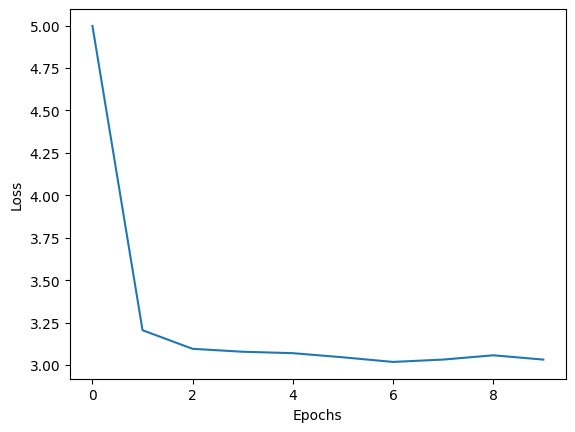

In [24]:

plt.plot(range(max_epochs), autoencoder.loss)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()

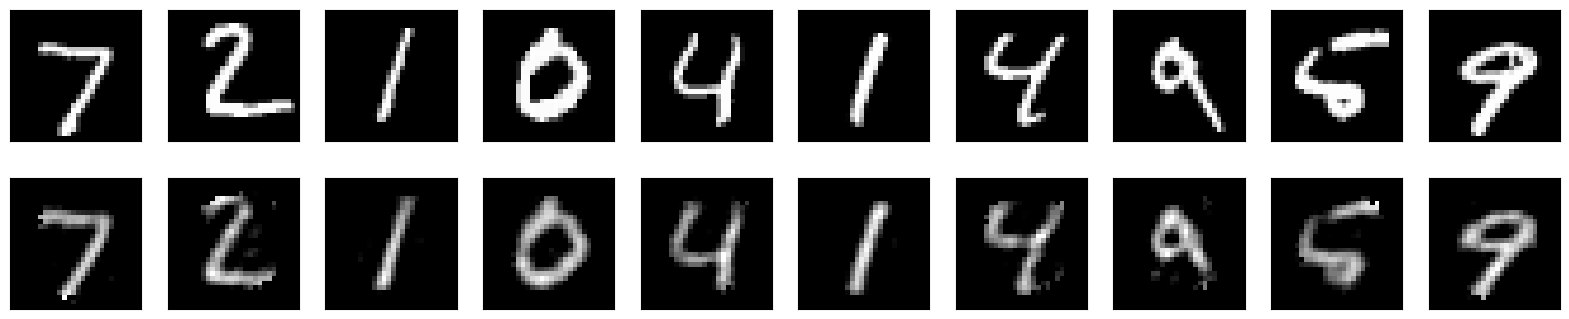

In [25]:
number = 10  # how many digits we will display
plt.figure(figsize=(20, 4))
for index in range(number):
    # display original
    ax = plt.subplot(2, number, index + 1)
    plt.imshow(x_test[index].reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # display reconstruction
    ax = plt.subplot(2, number, index + 1 + number)
    plt.imshow(autoencoder(x_test)[index].numpy().reshape(28, 28), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()